In [1]:
!pip install scikit-fuzzy numpy matplotlib networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 KB 19.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 100.7 MB/s eta 0:00:00


In [2]:
import numpy as np 
import skfuzzy as fuzz
from skfuzzy import control as ctrl 
import matplotlib.pyplot as plt

In [3]:
temparature = ctrl.Antecedent(np.arange(0,41,1),'temparature')

occupancy = ctrl.Antecedent(np.arange(0,11,1),'occupancy')

fan_speed = ctrl.Consequent(np.arange(0,101,1),'fan_speed')


In [4]:
temparature['cold']=fuzz.trimf(temparature.universe,[0,0,20])
temparature['warm']=fuzz.trimf(temparature.universe,[15,25,35])
temparature['hot']=fuzz.trimf(temparature.universe,[30,35,40])

In [5]:
occupancy['low']=fuzz.trimf(occupancy.universe,[0,0,3])
occupancy['medium']=fuzz.trimf(occupancy.universe,[3,5,8])
occupancy['high']=fuzz.trimf(occupancy.universe,[6,8,10])

In [6]:
fan_speed['slow']=fuzz.trimf(fan_speed.universe,[0,0,40])
fan_speed['medium']=fuzz.trimf(fan_speed.universe,[30,50,70])
fan_speed['fast']=fuzz.trimf(fan_speed.universe,[60,80,100])



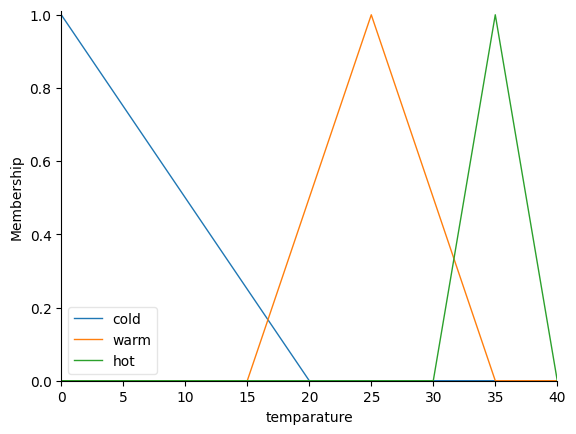

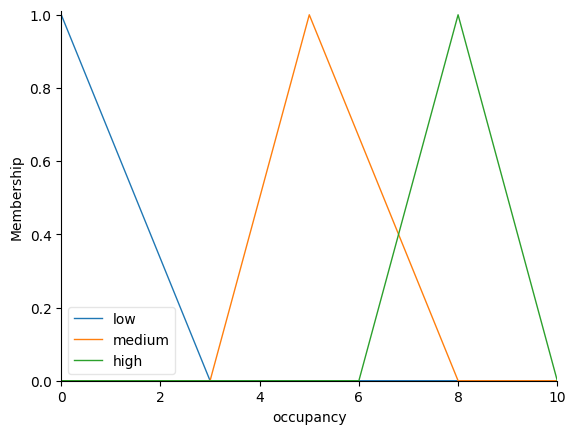

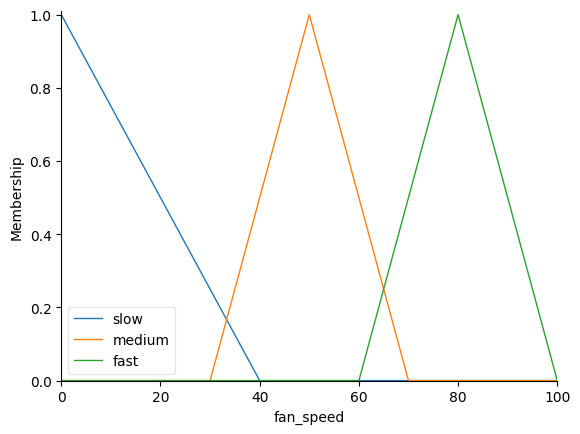

In [7]:
temparature.view()
occupancy.view()
fan_speed.view()

In [8]:
rule1=ctrl.Rule(temparature['cold'] & occupancy['low'], fan_speed['slow'])
rule2=ctrl.Rule(temparature['warm'] & occupancy['low'], fan_speed['slow'])
rule3=ctrl.Rule(temparature['hot'] & occupancy['low'], fan_speed['medium'])
rule4=ctrl.Rule(temparature['cold'] & occupancy['medium'], fan_speed['slow'])
rule5=ctrl.Rule(temparature['warm'] & occupancy['medium'], fan_speed['medium'])
rule6=ctrl.Rule(temparature['hot'] & occupancy['medium'], fan_speed['fast'])
rule7=ctrl.Rule(temparature['cold'] & occupancy['high'], fan_speed['medium'])
rule8=ctrl.Rule(temparature['warm'] & occupancy['high'], fan_speed['fast'])
rule9=ctrl.Rule(temparature['hot'] & occupancy['high'], fan_speed['fast'])


In [9]:
fan_controller=ctrl.ControlSystem([
    rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9
])

fan=ctrl.ControlSystemSimulation(fan_controller)

In [10]:
fan.input['temparature']=5
fan.input['occupancy']=2
fan.compute()
print("temparature : ",5)
print("occupancyp : ",2)
print("predicted fan speed: ",round(fan.output['fan_speed'],2),"%")


temparature :  5
occupancyp :  2
predicted fan speed:  16.89 %


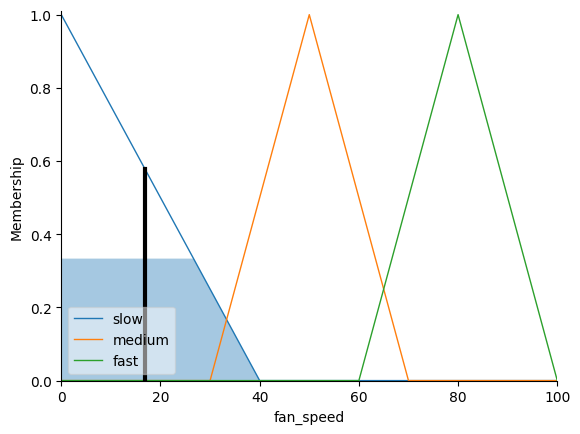

In [11]:
fan_speed.view(sim=fan)